# 07 · Comparativa de Modelos y Conclusiones

**Objetivo:** Comparar el rendimiento de todos los modelos entrenados y extraer conclusiones sobre las estrategias de fusión multimodal.

**Prerequisito:** Los modelos deben estar guardados en `../models/` (ejecutar notebooks 03–06 previamente).

## Carga de datos y modelos

Este notebook carga los modelos guardados en `../models/` y los evalúa sobre el mismo conjunto de test que se usó en el entrenamiento (split 70/15/15 con `random_state=42`).

**Prerequisito:** ejecutar los notebooks 03–06 al menos una vez para generar los archivos de modelo.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib
from collections import Counter
from sklearn.metrics import (accuracy_score, roc_curve, auc, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize

from utils import get_all_splits, get_tabular_splits

# ── Cargar datos de test (mismo split que en entrenamiento) ───────────────────
print("Cargando datos...")
(X_img_train, X_img_val, X_img_test,
 X_tab_train, X_tab_val, X_tab_test,
 y_train_all, _, y_test_all, le) = get_all_splits()

_, _, X_tab_test_only, _, _, y_test_tab, _ = get_tabular_splits()

y_true_all = np.argmax(y_test_all, axis=1)
y_true_tab = np.argmax(y_test_tab, axis=1)

# Baseline ZeroR: predecir siempre la clase más frecuente en train
y_train_lbl = np.argmax(y_train_all, axis=1)
most_common_class = Counter(y_train_lbl).most_common(1)[0][0]
baseline_acc = (y_true_all == most_common_class).mean()
print(f"\nBaseline ZeroR (predecir siempre '{le.classes_[most_common_class]}'): {baseline_acc:.2%}")

# ── Cargar modelos y calcular predicciones ────────────────────────────────────
print("\nCargando modelos...")

# Tabular
model_tab = tf.keras.models.load_model('../models/tabular_model.h5')
y_prob_tab = model_tab.predict(X_tab_test_only, verbose=0)
y_pred_tab = np.argmax(y_prob_tab, axis=1)

# CNN — acepta tanto Transfer Learning (.keras) como la CNN anterior (.h5)
cnn_path = '../models/cnn_model.keras' if os.path.exists('../models/cnn_model.keras') \
           else '../models/cnn_model.h5'
print(f"  CNN: cargando desde {cnn_path}")
model_cnn = tf.keras.models.load_model(cnn_path)
y_prob_cnn = model_cnn.predict(X_img_test, verbose=0)
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)

# Early Fusion (mejor modelo)
model_ef = tf.keras.models.load_model('../models/mejor_modelo_early_fusion.keras')
y_prob_ef = model_ef.predict([X_img_test, X_tab_test], verbose=0)
y_pred_ef = np.argmax(y_prob_ef, axis=1)

# Late Fusion (SVM sobre probabilidades de dos submodelos)
model_lf_img = tf.keras.models.load_model('../models/late_fusion_image_model.h5')
model_lf_tab = tf.keras.models.load_model('../models/late_fusion_tabular_model.h5')
clf_svm = joblib.load('../models/late_fusion_svm.pkl')
pred_lf_img = model_lf_img.predict(X_img_test, verbose=0)
pred_lf_tab = model_lf_tab.predict(X_tab_test, verbose=0)
y_prob_lf = clf_svm.predict_proba(np.concatenate([pred_lf_img, pred_lf_tab], axis=1))
y_pred_lf = np.argmax(y_prob_lf, axis=1)

print("Modelos cargados correctamente.")

Cargando datos...
Imágenes+Tabular — Train: 7010 | Val: 1502 | Test: 1503
Shape imágenes: (28, 28, 3) | Features tabular: 17
Clases: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
Tabular — Train: 7010 | Val: 1502 | Test: 1503
Clases: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']

Baseline ZeroR (predecir siempre 'nv'): 66.93%

Cargando modelos...
  CNN: cargando desde ../models/cnn_model.keras

Modelos cargados correctamente.


## Tabla comparativa de resultados

Comparamos todos los modelos frente al **Baseline ZeroR**: un clasificador que predice siempre la clase más frecuente (nevus, ~67%). Sin este punto de referencia, un 69% de accuracy no parece ninguna mejora.

In [ ]:
modelos_info = [
    ('Red Densa (tabular)', 'Solo metadatos',           y_pred_tab, y_true_tab, '~5K'),
    ('CNN Transfer Learning','Solo imágenes',            y_pred_cnn, y_true_all, '~5.4M'),
    ('Late Fusion (SVM)',   'Imágenes + metadatos',     y_pred_lf,  y_true_all, '~900K'),
    ('Early Fusion',        'Imágenes + metadatos',     y_pred_ef,  y_true_all, '~850K'),
    ('Baseline ZeroR',      'Clase mayoritaria siempre',
     np.full_like(y_true_all, most_common_class),       y_true_all, '0'),
]

rows = []
for nombre, datos, y_pred_, y_true_, params in modelos_info:
    acc = accuracy_score(y_true_, y_pred_)
    mejora = acc - baseline_acc
    rows.append({'Modelo': nombre, 'Datos': datos,
                 'Accuracy': f'{acc:.2%}',
                 'Mejora vs ZeroR': f'{mejora:+.2%}',
                 'Parámetros': params})

df = pd.DataFrame(rows)
display(df)

## Curvas ROC — Early Fusion (mejor modelo)

La curva ROC muestra cómo de bueno es el modelo separando cada enfermedad del resto. El **AUC** (área bajo la curva) resume esto en un número: 1.0 = perfecto, 0.5 = aleatorio.

Mostramos las curvas del **Early Fusion** por ser el mejor modelo. Un AUC alto en **melanoma** (`mel`) es especialmente importante: un falso negativo tiene consecuencias clínicas graves.

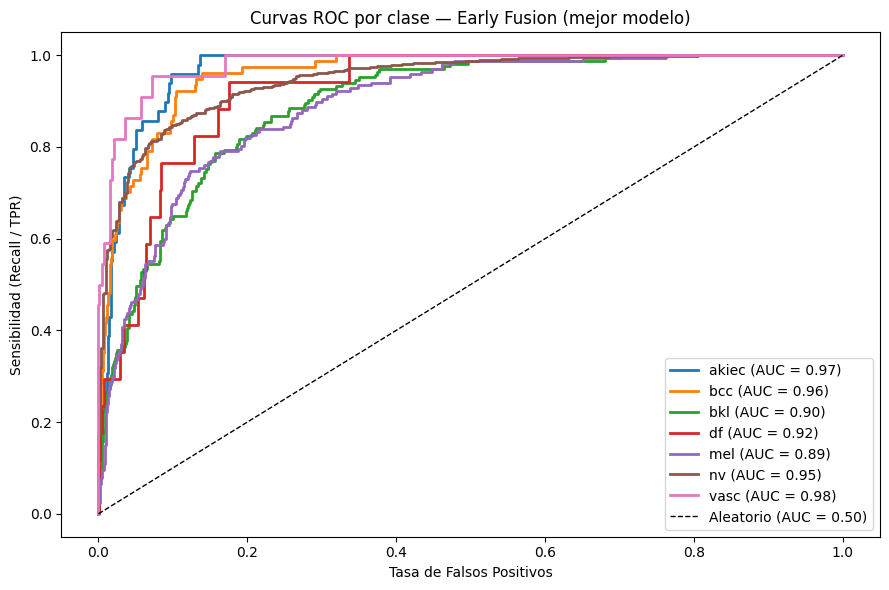

AUC macro Early Fusion: 0.9386


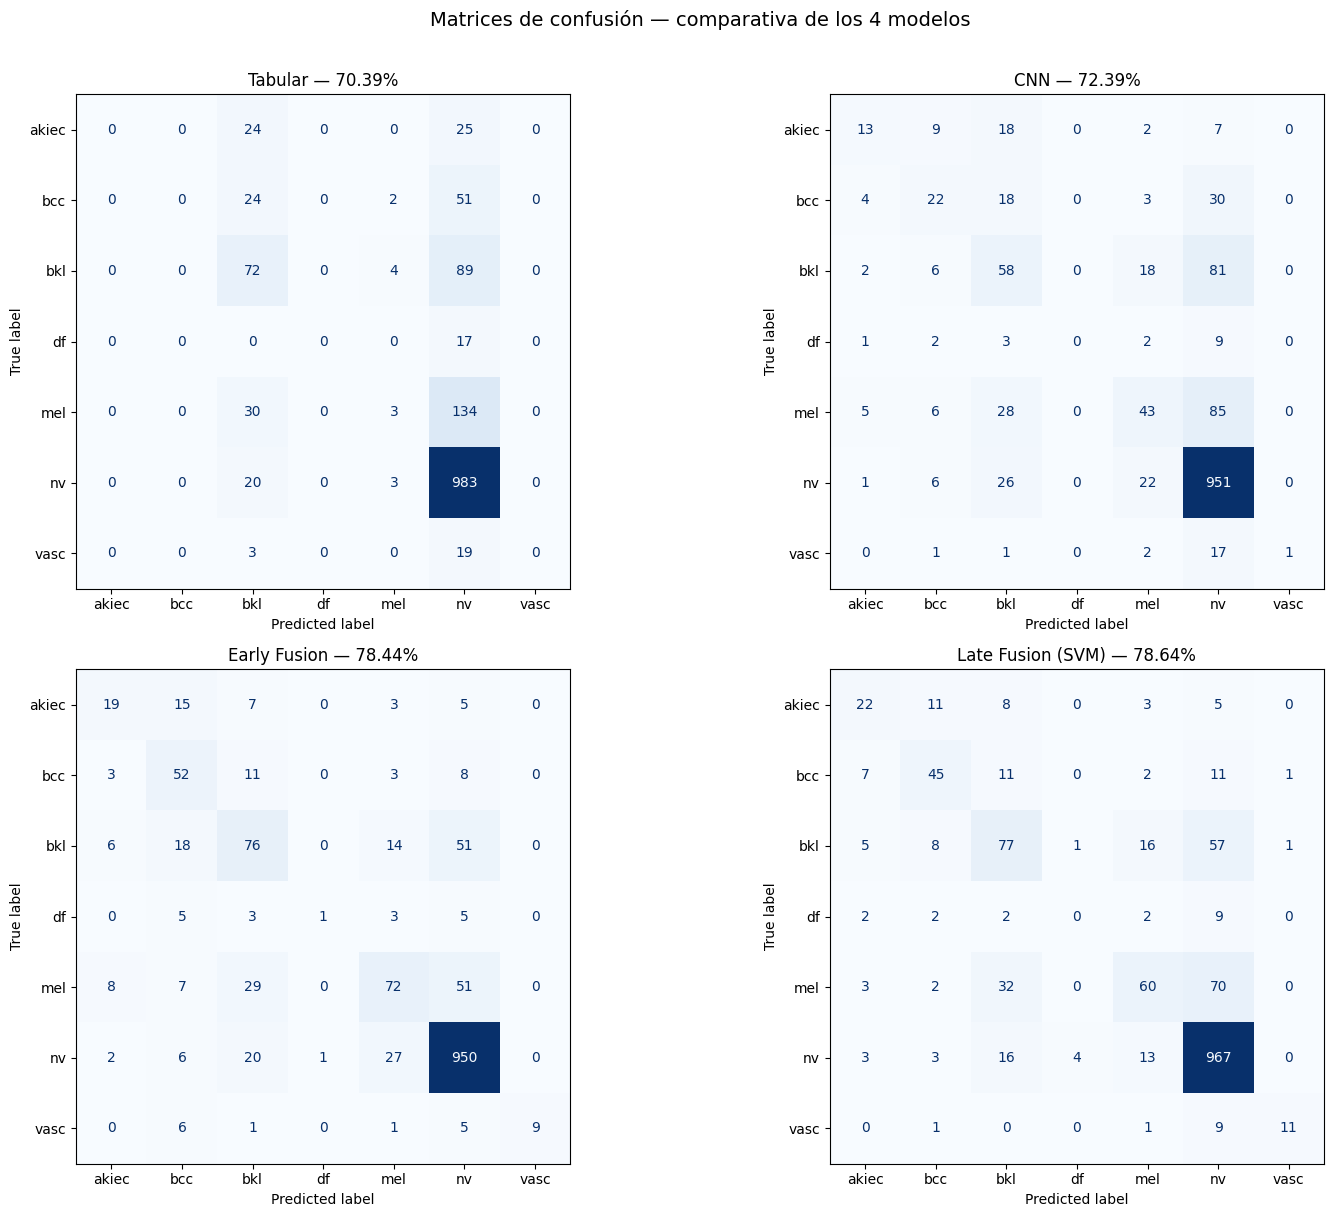

In [3]:
# ── Curvas ROC: Early Fusion ──────────────────────────────────────────────────
y_true_bin = label_binarize(y_true_all, classes=range(len(le.classes_)))

fig, ax = plt.subplots(figsize=(9, 6))
for i, (clase, color) in enumerate(zip(le.classes_, plt.cm.tab10.colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_ef[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{clase} (AUC = {auc(fpr, tpr):.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0.50)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Sensibilidad (Recall / TPR)')
ax.set_title('Curvas ROC por clase — Early Fusion (mejor modelo)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_true_bin, y_prob_ef, multi_class='ovr', average='macro')
print(f'AUC macro Early Fusion: {macro_auc:.4f}')

# ── Matrices de confusión — comparativa ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

cuadros = [
    ('Tabular',          y_pred_tab, y_true_tab),
    ('CNN',              y_pred_cnn, y_true_all),
    ('Early Fusion',     y_pred_ef,  y_true_all),
    ('Late Fusion (SVM)', y_pred_lf, y_true_all),
]

for ax, (nombre, y_pred_, y_true_) in zip(axes, cuadros):
    cm = confusion_matrix(y_true_, y_pred_)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_true_, y_pred_)
    ax.set_title(f'{nombre} — {acc:.2%}')

plt.suptitle('Matrices de confusión — comparativa de los 4 modelos', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Conclusiones finales:

Hemos terminado nuestro trabajo, creando distintos modelos (1D, 2D, 3D con Early fusion y late fusion, e incluso un modelo que analiza las imágenes en forma de tensor para así conseguir encontrar patrones entre los valores de sus píxeles)
En primer lugar, hemos quitado las variables que no nos valían, y hemos codificado los posibles diagnósticos para que así nuestros modelos puedan trabajar con ellos. 

Como hemos observado, el modelo que peor ha funcionado ha sido el modelo tabular, que nos ha dado valores muy bajos, dado que por ejemplo la edad no debería ser un valor MUY determinante (habrá lesiones que sean más frecuentes según el grupo de edad, y ahí afectarán factores más bien sociológicos,  pero entiendo que todas las lesiones pueden afectar a cualquier grupo de edad)
El modelo que mejores resultados nos ha dado ha sido el Early fusion, llegando a alcanzar valores de 0.78 (aún no muy altos, pero prometedores)

### Posibles mejoras:
- Fine-tuning de modelos preentrenados: Dado que el trabajo consistía en CREAR nuestra propia red, no he valorado esta opción, pero podría ser una buena idea.  Podríamos utilizar redes convolucionales preentrenadas, como ResNet, EfficientNet o VGG, y hacer un ajuste fino con nuestro dataset. Esto permitiría que la red aproveche patrones previamente aprendidos, acelerando el entrenamiento y mejorando la capacidad de generalización.

- Aumento de datos (Data Augmentation): Para el modelo de imágenes, aplicar transformaciones ligeras como rotaciones, traslaciones, zoom o cambios de brillo puede ayudar a reducir el overfitting y enseñar a la red a reconocer lesiones en distintas posiciones o condiciones de iluminación.

- Optimización de la fusión: Para los modelos de Early y Late Fusion, podríamos experimentar con ponderar más las salidas de la imagen frente a los datos tabulares, dado que el modelo tabular mostró menor relevancia. También se podría probar fusionar capas intermedias en lugar de solo al final, para capturar mejor las relaciones entre imágenes y variables tabulares.

- Experimentar distintas tasas de aprendizaje: Ajustar hiperparámetros como el learning rate

- Enriquecer el dataset: Si es posible, aumentar la cantidad de imágenes o incluir datasets externos similares puede mejorar notablemente la capacidad de generalización de los modelos.





## Trabajo futuro

1. **Transfer Learning** con EfficientNetB0 o ResNet50 — potencial mejora de +10-15% en accuracy.
2. **Data Augmentation** agresiva (rotaciones, flips, variaciones de brillo) para regularizar la CNN.
3. **class_weight** para penalizar los errores en clases minoritarias (especialmente melanoma).
4. **Métricas médicas**: sensitivity y specificity por clase, AUC-ROC — el accuracy global no es suficiente en diagnóstico médico donde un falso negativo de melanoma tiene consecuencias graves.